# Raster and PSTH Plotting
This notebook uses `PSTH_raster.py` for all plotting functions and keeps only one basic trial-structure check.

In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
%load_ext autoreload
%autoreload 2

import load_nwb
from load_nwb import nwb_loader
import nwb_data_prep as nwb_prep
import pca_data_prep as prep
import prep_data as data_prep
import PSTH_raster as psth_raster
import verify_data as verify

prep = importlib.reload(prep)
nwb_prep = importlib.reload(nwb_prep)
data_prep = importlib.reload(data_prep)
psth_raster = importlib.reload(psth_raster)
verify = importlib.reload(verify)

## Load Session From `.env`

In [2]:
session_data_dic = prep.load_env()
session_data_dic

MOUSE loaded: Reach15




-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- First Neuropixels File --
NP_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
DATE loaded: 20260129
SESSION loaded: session003
BOMBCELL loaded: bombcell_batch_20260305_1130
PROBE_A_CH_CONFIG loaded: probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_C_CH_CONFIG loaded: probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_D_CH_CONFIG loaded: probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json


-- Second Neuropixels File --
NP_FILE loaded: Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32
NWB_FILE loaded: NA
DATE_01 loaded: 20260129
SESSION_01 loaded: session004
BOMBCELL_01 loaded: NA
PROBE_A_CH_CONFIG_01 loaded: NA
PROBE_C_CH_CONFIG_01 loaded: NA
PROBE_D_CH_CONFIG_01 loa

{'MOUSE': 'Reach15',
 'BEHAVIORAL_FOLDER': 'grant_reach15_swingDoor-christie',
 'NP_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'DATE': '20260129',
 'SESSION': 'session003',
 'BOMBCELL': 'bombcell_batch_20260305_1130',
 'NWB_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'PROBE_A_CH_CONFIG': 'probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_C_CH_CONFIG': 'probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_D_CH_CONFIG': 'probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'NP_FILE_01': 'Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32',
 'DATE_01': '20260129',
 'SESSION_01': 'session004',
 'BOMBCELL_01': 'NA',
 'NWB_FILE_01': 'NA',
 'PROBE_A_CH_CONFIG_01': 'NA',
 'PROBE_C_CH_CONFIG_01': 'NA',
 'PROBE_D_CH_CONFIG_01': 'NA',
 'NP_FILE_02': 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00',
 'DA

In [3]:
SESSION_TO_ANALYZE = 3

MOUSE, BEHAVIORAL_FOLDER, PROBE_A_CH_CONFIG, PROBE_C_CH_CONFIG, PROBE_D_CH_CONFIG, NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL = prep.session_to_analyze(
    session_data_dic['MOUSE'],
    session_data_dic['BEHAVIORAL_FOLDER'],
    session_data_dic['NP_FILE'],
    session_data_dic['NWB_FILE'],
    session_data_dic['DATE'],
    session_data_dic['SESSION'],
    session_data_dic['BOMBCELL'],
    session_data_dic['PROBE_A_CH_CONFIG'],
    session_data_dic['PROBE_C_CH_CONFIG'],
    session_data_dic['PROBE_D_CH_CONFIG'],
    session_data_dic['NP_FILE_01'],
    session_data_dic['NWB_FILE_01'],
    session_data_dic['DATE_01'],
    session_data_dic['SESSION_01'],
    session_data_dic['BOMBCELL_01'],
    session_data_dic['PROBE_A_CH_CONFIG_01'],
    session_data_dic['PROBE_C_CH_CONFIG_01'],
    session_data_dic['PROBE_D_CH_CONFIG_01'],
    session_data_dic['NP_FILE_02'],
    session_data_dic['NWB_FILE_02'],
    session_data_dic['DATE_02'],
    session_data_dic['SESSION_02'],
    session_data_dic['BOMBCELL_02'],
    session_data_dic['PROBE_A_CH_CONFIG_02'],
    session_data_dic['PROBE_C_CH_CONFIG_02'],
    session_data_dic['PROBE_D_CH_CONFIG_02'],
    session_selection=SESSION_TO_ANALYZE,
)

PROBES = ['A', 'B', 'C', 'D', 'E', 'F']
paths_dic = prep.setup_paths_and_verify(PROBES, NWB_FILE, NP_FILE, DATE, SESSION, BEHAVIORAL_FOLDER, BOMBCELL)
paths_dic


SESSION SELECTION:

NP_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
NWB_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
DATE: 20260201
SESSION: session007
BEHAVIORAL_FOLDER: grant_reach15_swingDoor-christie
BOMBCELL: bombcell_batch_20260304_1536
PROBE_A_CH_CONFIG: probeA_SIM_IP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_C_CH_CONFIG: probeC_MoP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_D_CH_CONFIG: probeD_VaL__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
✅ Found bombcell data for probe A at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536\kilosort4_A
✅ Found bombcell data for probe B at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_202

{'NP_ROOT_DIR': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00'),
 'NWB_PATH': WindowsPath('H:/NWB_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00'),
 'BOMBCELL_ROOT_FOR_AUTO_BUILD': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260304_1536'),
 'baseline_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260201\\christielab\\session007\\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy',
 'washout_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260201\\christielab\\session007\\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy',
 'optoicalStim_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\

## Load NWB, Processed Bundle, and Event Arrays

In [4]:
mouse_nwb = paths_dic['NWB_PATH']
baseline_trials_index_path = paths_dic['baseline_trials_index_path']
washout_trials_index_path = paths_dic['washout_trials_index_path']
optoicalStim_trials_index_path = paths_dic['optoicalStim_trials_index_path']
BOMBCELL_ROOT_FOR_AUTO_BUILD = paths_dic['BOMBCELL_ROOT_FOR_AUTO_BUILD']

mouse_id = load_nwb.nwb_loader(mouse_nwb)
df_stim, df_units = nwb_loader.verify_nwb_data(mouse_id)

PROCESSED_BUNDLE_SESSION_DIR = Path.cwd().resolve() / 'processed_data' / NP_FILE
PROCESSED_BUNDLE_SESSION_DIR.mkdir(parents=True, exist_ok=True)

bundle, merged_dic, stim_df, df_stim, pca_event_meta_bundle, extras, meta, PROCESSED_BUNDLE_DIR = nwb_prep.load_or_build_processed_bundle(
    processed_bundle_dir=PROCESSED_BUNDLE_SESSION_DIR,
    nwb_path_for_auto_build=mouse_nwb,
    bombcell_root_for_auto_build=BOMBCELL_ROOT_FOR_AUTO_BUILD,
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=('merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl'),
    verbose=True,
)

baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

tone1_start_times, tone2_start_times, frame_events_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = data_prep.extract_start_times(df_stim)
(
    total_optical_timestamps,
    total_optoTagging_timestamps,
    total_opto_tagging_events,
    total_opto_tagging_pulses,
    first_opto_tagging_timestamp,
    end_opto_tagging_index,
    last_tone2_time,
    start_of_opto_tagging_index,
    behavioral_video_duration,
    final_behavioral_video_time,
    opto_closed_loop_start_timestamps,
    opto_tag_start_timestamps,
    last_closed_loop_start_time,
    first_opto_tagging_timestamp_per_trial,
    first_optical_pulse_per_closed_loop,
) = data_prep.seperate_closedLoop_optoTagging(
    optical_start_times,
    tone2_start_times,
    frame_events_start_times,
    total_opto_tagging_events=60,
    pulses_per_event=10,
)

pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times, baseline_reachInit_stimROI_start_times, stimulation_reachInit_stimROI_start_times, washout_reachInit_stimROI_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx,
)

EVENT_TIME_ALIGN_TO = 'all_stimROI_triggers_start_times'
pca_event_meta_aligned, EVENT_TIME_ALIGN_REPORT = prep.align_pca_event_meta_start_times(
    pca_event_meta=pca_event_meta,
    align_to=EVENT_TIME_ALIGN_TO,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    baseline_reachInit_stimROI_start_times=baseline_reachInit_stimROI_start_times,
    stimulation_reachInit_stimROI_start_times=stimulation_reachInit_stimROI_start_times,
    washout_reachInit_stimROI_start_times=washout_reachInit_stimROI_start_times,
    custom_event_start_times=None,
    mismatch='index_then_nearest',
    max_delta_s=None,
    drop_unmatched=True,
)

df_stim = prep.relabel_df_stim_block_labels(
    df_stim,
    pca_event_meta_aligned,
)
stim_df = prep.relabel_df_stim_block_labels(
    stim_df,
    pca_event_meta_aligned,
)

verification_output_dir = Path.cwd().resolve() / 'processed_data' / NP_FILE / 'verification'
verification_output_dir.mkdir(parents=True, exist_ok=True)

output_root = Path(r'H:\PSTH_RASTER_OUT') / str(NP_FILE)

loaded NWB from: H:\NWB_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00

===== Total units Per Probe ====
A:  554
B:  1316
C:  355
D:  820
E:  864
F:  691

 ======= Unique stimulus types ==========   : 
 ['tone1_timestamps' 'tone2_timestamps' 'stimROI_timestamps'
 'frame_events_timestamp' 'optical_timestamps'
 'reachInit_stimROI_timestamps' 'opto_tagging_timestamps'
 'baseline_reachInit_stimROI_timestamps'
 'stimulation_reachInit_stimROI_timestamps'
 'washout_reachInit_stimROI_timestamps']

===== Total Timestamps Per Event ====
tone1_timestamps:  376
tone2_timestamps:  270
stimROI_timestamps:  130
frame_events_timestamp:  1349818
optical_timestamps:  1900
reachInit_stimROI_timestamps:  270
opto_tagging_timestamps:  60
baseline_reachInit_stimROI_timestamps:  20
stimulation_reachInit_stimROI_timestamps:  130
washout_reachInit_stimROI_timestamps:  120


Loaded bundle: C:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\processed_dat

## Plotting Setup

In [26]:
df_plot_units = psth_raster.combine_merged_units(merged_dic)
if df_plot_units.empty:
    df_plot_units = df_units.copy()

if 'Brain_Region' not in df_plot_units.columns and 'brain_region' in df_plot_units.columns:
    df_plot_units = df_plot_units.rename(columns={'brain_region': 'Brain_Region'})

trial_indices_stim_seperated = psth_raster.build_trial_index_groups(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    one_based=True,
)

reach_Init_from_StimROI_with_STIM = stimulation_reachInit_stimROI_start_times
reach_Init_from_StimROI_without_STIM = washout_reachInit_stimROI_start_times
reach_Init_baseline = baseline_reachInit_stimROI_start_times
all_reach_Init_from_StimROI = np.concatenate([
    reach_Init_baseline,
    reach_Init_from_StimROI_with_STIM,
    reach_Init_from_StimROI_without_STIM,
])
all_reach_Init_from_StimROI = np.sort(all_reach_Init_from_StimROI)

available_probes = sorted(df_plot_units['probe'].dropna().astype(str).unique())

if 'KSlabel' in df_plot_units.columns:
    example_good_units = df_plot_units[
        pd.to_numeric(df_plot_units['KSlabel'], errors='coerce') == 2
    ].copy()
else:
    example_good_units = pd.DataFrame(columns=df_plot_units.columns)

example_use_kslabel = not example_good_units.empty
example_source_units = example_good_units if example_use_kslabel else df_plot_units.copy()

if example_source_units.empty:
    raise ValueError('No units available for plotting examples.')

available_probes = sorted(example_source_units['probe'].dropna().astype(str).unique())
example_units_by_probe = (
    example_source_units.dropna(subset=['cluster_id'])
    .sort_values(['probe', 'cluster_id'])
    .groupby('probe')['cluster_id']
    .first()
    .astype(int)
    .to_dict()
)
example_regions_by_probe = {}
for probe in available_probes:
    probe_df = example_source_units[example_source_units['probe'].astype(str) == probe]
    if 'Brain_Region' in probe_df.columns:
        values = probe_df['Brain_Region'].dropna().astype(str)
        example_regions_by_probe[probe] = values.iloc[0] if len(values) else 'unknown_region'
    else:
        example_regions_by_probe[probe] = 'unknown_region'

probeLetter = 'A' if 'A' in example_units_by_probe else available_probes[0]
cluster_id = int(example_units_by_probe[probeLetter])
brain_region = example_regions_by_probe[probeLetter]
brain_region_filter = brain_region if brain_region != 'unknown_region' else None
pre = 1.5
post = 1.5
bin_size = 0.01

single_event_name_subplots = psth_raster.build_event_name_subplots(
    (all_stimROI_triggers_start_times, 'all_trials'),
    namespace=globals(),
)

event_name_subplots = psth_raster.build_event_name_subplots(
    (tone1_start_times, 'all_trials'),
    (tone2_start_times, 'all_trials'),
    (all_reach_Init_from_StimROI, 'all_trials'),
    (reach_Init_from_StimROI_with_STIM, 'stimulation_trials'),
    (reach_Init_from_StimROI_without_STIM, 'washout_trials'),
    namespace=globals(),
)

variables = {
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
    'all_reach_Init_from_StimROI': all_reach_Init_from_StimROI,
    'reach_Init_from_StimROI_with_STIM': reach_Init_from_StimROI_with_STIM,
    'reach_Init_from_StimROI_without_STIM': reach_Init_from_StimROI_without_STIM,
    'first_opto_tagging_timestamp_per_trial': first_opto_tagging_timestamp_per_trial,
    'first_optical_pulse_per_closed_loop': first_optical_pulse_per_closed_loop,
}

plot_output_root = Path.cwd().resolve() / 'processed_data' / NP_FILE / 'psth_raster_outputs'
plot_output_root.mkdir(parents=True, exist_ok=True)

# Keep the batch examples small so the notebook stays practical.
probe_example_units = (
    example_source_units[example_source_units['probe'].astype(str) == probeLetter]
    .sort_values('cluster_id')
    .copy()
)
if brain_region_filter is not None and 'Brain_Region' in probe_example_units.columns:
    region_example_units = probe_example_units[
        probe_example_units['Brain_Region'].astype(str) == brain_region_filter
    ].copy()
    if region_example_units.empty:
        brain_region_filter = None
        region_example_units = probe_example_units.copy()
else:
    region_example_units = probe_example_units.copy()

df_probe_subset = region_example_units.head(5).copy()
if df_probe_subset.empty:
    raise ValueError(f'No example units available for probe {probeLetter}.')
selected_units_for_heatmap = (
    probe_example_units['cluster_id']
    .dropna()
    .head(12)
    .astype(int)
    .tolist()
)

multi_probe_letters = []
multi_region_units = []
multi_region_labels = []
selected_units_by_probe = {}
for probe in available_probes:
    probe_df = (
        example_source_units[example_source_units['probe'].astype(str) == probe]
        .sort_values('cluster_id')
        .copy()
    )
    if probe_df.empty:
        continue
    multi_probe_letters.append(probe)
    multi_region_units.append(int(probe_df['cluster_id'].dropna().astype(int).iloc[0]))
    if 'Brain_Region' in probe_df.columns:
        values = probe_df['Brain_Region'].dropna().astype(str)
        multi_region_labels.append(values.iloc[0] if len(values) else 'unknown_region')
    else:
        multi_region_labels.append('unknown_region')
    selected_units_by_probe[probe] = (
        probe_df['cluster_id']
        .dropna()
        .astype(int)
        .head(10)
        .tolist()
    )


## Basic Trial Structure Check

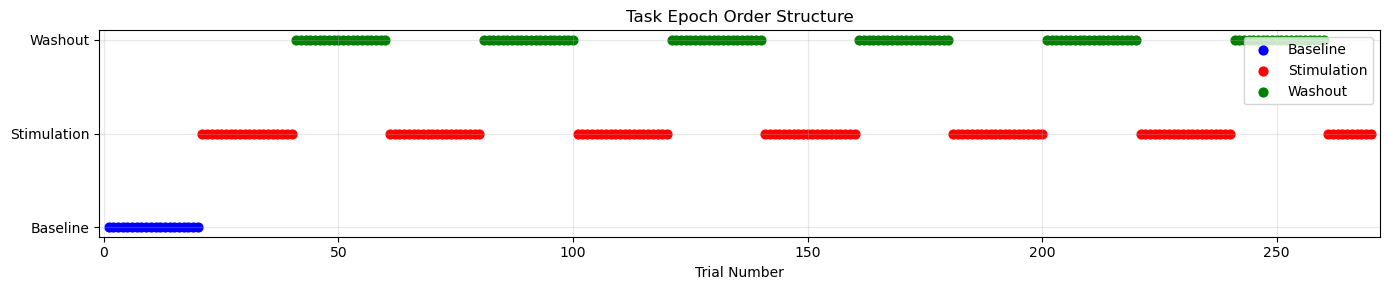

In [27]:
verify.plot_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_are_one_based=True,
    figsize=(14, 3),
)

### Verify df_units

In [28]:
df_units

,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
0,0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,NOISE,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,NOISE,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,NOISE,"[9938.29451763671, 9938.519134975282, 9938.609..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,4595,860.0,43.0,3740.0,0,1,10.2,175.3,F,OUT_ROI,None,NON-SOMA,"[9939.57044788735, 9939.597083318817, 9939.703..."
4596,4596,1020.0,43.0,3580.0,0,2,19.5,0.0,F,OUT_ROI,None,NOISE,"[10919.660133182651, 10919.6751343645, 10919.7..."
4597,4597,1060.0,11.0,3540.0,0,1,9.6,236.7,F,OUT_ROI,None,NOISE,"[9996.778036617923, 10049.712567383913, 10050...."
4598,4598,980.0,43.0,3620.0,0,2,26.1,0.0,F,OUT_ROI,None,NON-SOMA,"[10919.650099059141, 10919.665100240469, 10919..."


### Verify df_stim

,start_time,stop_time,stimulus,optogenetics_LED_state,event_time_s,block_id,is_opto,block_label,trial_index,label,...,block_label_align_method,block_label_source,pca_trial_start_time,pca_trial_index0,epoch_id,real_epoch_id,condition,condition_epoch,real_condition,real_condition_epoch
0,10028.508867,10028.508867,frame_events_timestamp,0,10028.508867,0,False,baseline_epoch,0,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,10239.8933,0,0,0,baseline,baseline_epoch,baseline,baseline_epoch
1,10028.515500,10028.515500,frame_events_timestamp,0,10028.515500,0,False,baseline_epoch,1,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,10239.8933,0,0,0,baseline,baseline_epoch,baseline,baseline_epoch
2,10028.522200,10028.522200,frame_events_timestamp,0,10028.522200,0,False,baseline_epoch,2,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,10239.8933,0,0,0,baseline,baseline_epoch,baseline,baseline_epoch
3,10028.528833,10028.528833,frame_events_timestamp,0,10028.528833,0,False,baseline_epoch,3,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,10239.8933,0,0,0,baseline,baseline_epoch,baseline,baseline_epoch
4,10028.535533,10028.535533,frame_events_timestamp,0,10028.535533,0,False,baseline_epoch,4,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,10239.8933,0,0,0,baseline,baseline_epoch,baseline,baseline_epoch
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1353089,19028.808167,19028.808167,frame_events_timestamp,0,19028.808167,260,False,stimulation_epoch_5,1353089,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,18785.4879,269,5,5,stimulation,stimulation_epoch_5,stimulation,stimulation_epoch_5
1353090,19028.814867,19028.814867,frame_events_timestamp,0,19028.814867,260,False,stimulation_epoch_5,1353090,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,18785.4879,269,5,5,stimulation,stimulation_epoch_5,stimulation,stimulation_epoch_5
1353091,19028.821500,19028.821500,frame_events_timestamp,0,19028.821500,260,False,stimulation_epoch_5,1353091,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,18785.4879,269,5,5,stimulation,stimulation_epoch_5,stimulation,stimulation_epoch_5
1353092,19028.828200,19028.828200,frame_events_timestamp,0,19028.828200,260,False,stimulation_epoch_5,1353092,frame_events_timestamp,...,nearest_trial_start,real_condition_epoch,18785.4879,269,5,5,stimulation,stimulation_epoch_5,stimulation,stimulation_epoch_5


['frame_events_timestamp' 'tone1_timestamps'
 'reachInit_stimROI_timestamps' 'tone2_timestamps'
 'baseline_reachInit_stimROI_timestamps' 'optical_timestamps'
 'stimulation_reachInit_stimROI_timestamps' 'stimROI_timestamps'
 'washout_reachInit_stimROI_timestamps' 'opto_tagging_timestamps']


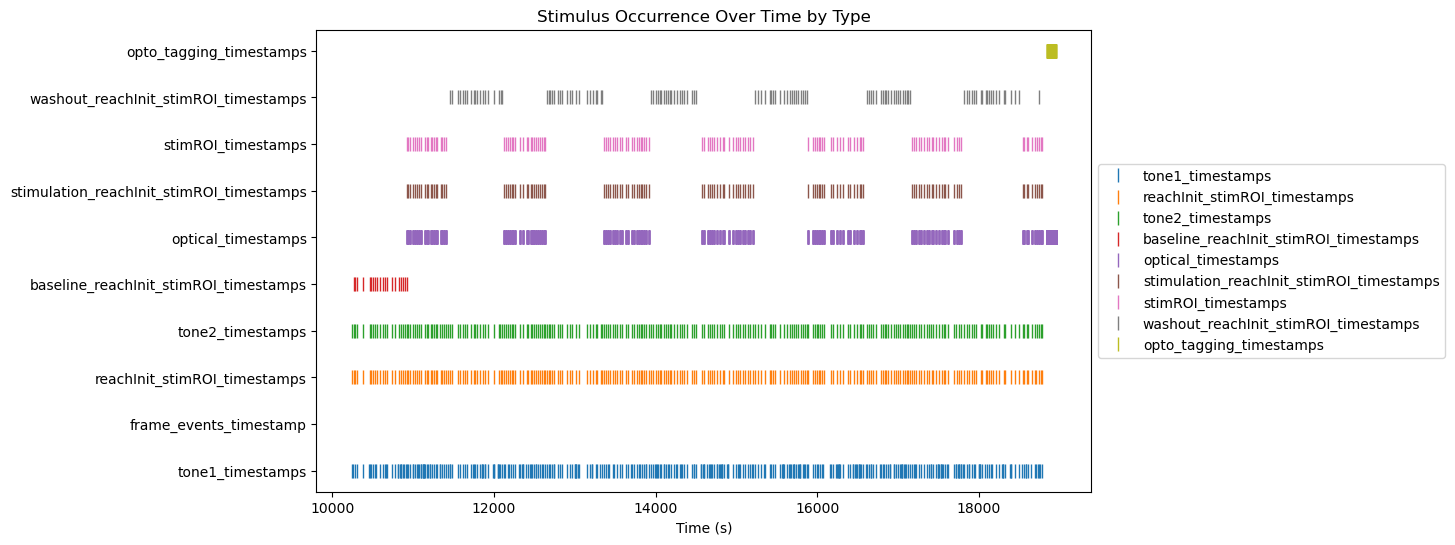

In [29]:
display(df_stim)
stimulus_types = df_stim['stimulus'].unique()
print(stimulus_types)
# use stimulus types as the Y-axis instead of trial index, and plot each stimulus type in a different color.
plt.figure(figsize=(10, 6))
for stimulus_type in stimulus_types:
    if stimulus_type == 'frame_events_timestamp':
        continue  # Skip the 'none' stimulus type if it exists
    stimulus_times = df_stim[df_stim.stimulus == stimulus_type]['event_time_s']
    plt.plot(stimulus_times, [stimulus_type] * len(stimulus_times), '|', label=stimulus_type, markersize=10)
    plt.xlabel('Time (s)')
    plt.yticks(stimulus_types)
    # place legend outside the plot area to avoid overlapping with data points
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title('Stimulus Occurrence Over Time by Type')
    

## Single-Unit Plots

(<Figure size 1000x800 with 2 Axes>,
 array([<Axes: title={'center': 'cluster_id: 0 | probe: A | BR: unknown_region | bc_unitType: NOISE | KS_label: good | Manual_label: No Manual Label Added | n_spikes: 14579\ndepth: 3120.00 | pre: 1.50 s | post: 1.50 s | bin_size: 0.010 s | event: all_stimROI_triggers_start_times | trial_type: all_trials | n_events: 270 | n_trials: 270 | smooth: yes | smooth_window: 5\nmean_baseline: 0.01 | std_baseline: 0.12 | mean_response: 0.01 | std_response: 0.11\ndelta_mean: -0.00 | trials_zMean: -0.02 | peak_delta: 10.36 Hz @ 0.02 s | peak_rate: 10.37 Hz'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
        <Axes: title={'center': 'all_stimROI_triggers_start_times | Raster Plot | trial_type: all_trials | n_trials: 270 | n_events: 270 | trial_z range: -0.10 to 1.10'}, xlabel='Time [s]', ylabel='Trial'>],
       dtype=object))

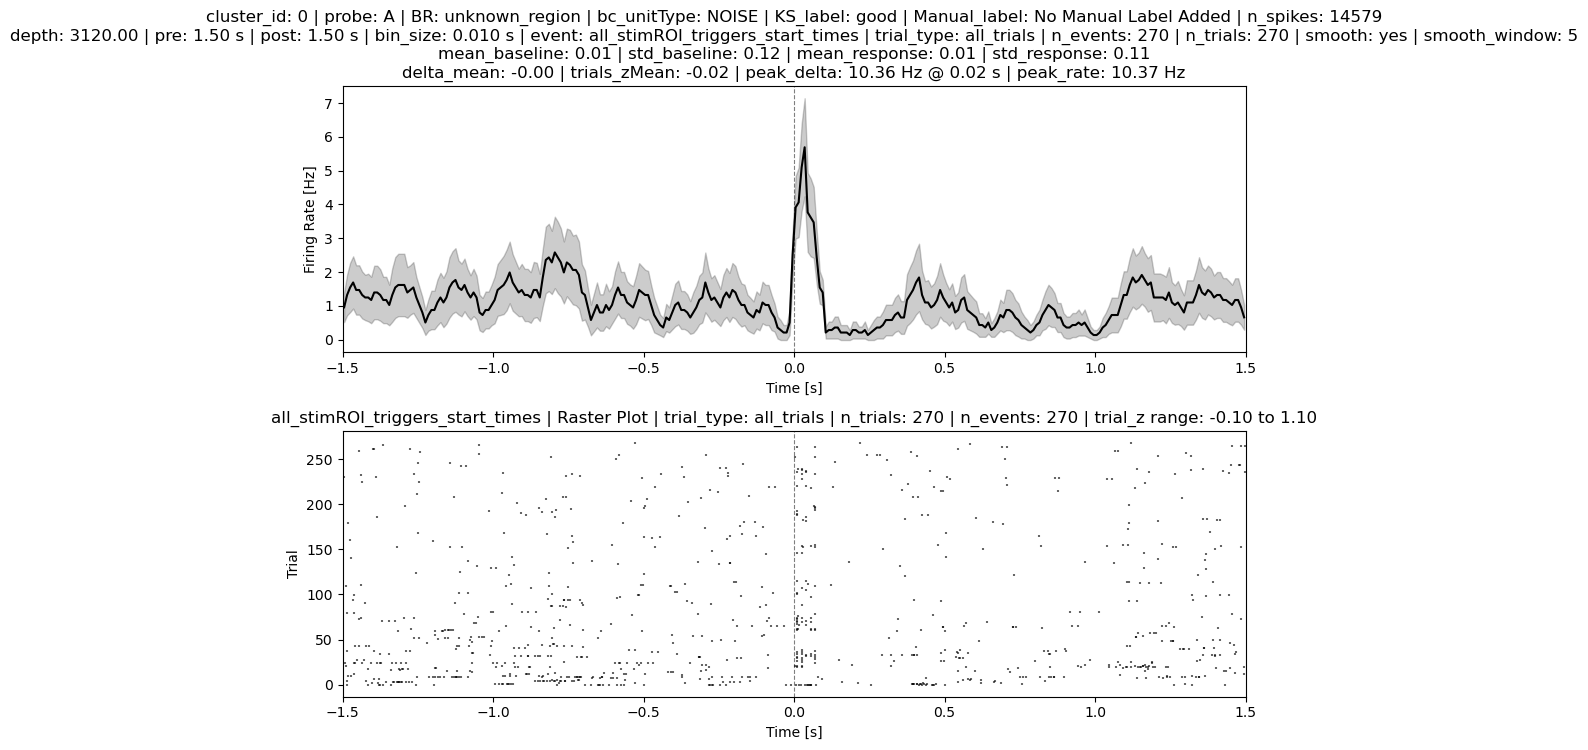

In [30]:
psth_raster.singleUnit_psth_raster_test(
    df_units=df_plot_units,
    probeLetter=probeLetter,
    cluster_id=cluster_id,
    event_name_subplots=single_event_name_subplots,
    pre=pre,
    post=post,
    bin_size=bin_size,
    namespace=globals(),
    var_bars=True
)

(<Figure size 3000x800 with 10 Axes>,
 array([[<Axes: title={'center': 'tone1_start_times\nall_trials\nn_events: 376 | n_trials: 376 | mean_baseline: 0.02 | std_baseline: 0.14\nmean_response: 0.02 | delta_mean: 0.00 | trials_zMean: 0.01 | peak_delta: 11.95 Hz @ 0.01 s'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'tone2_start_times\nall_trials\nn_events: 270 | n_trials: 270 | mean_baseline: 0.02 | std_baseline: 0.14\nmean_response: 0.01 | delta_mean: -0.01 | trials_zMean: -0.04 | peak_delta: 9.24 Hz @ 0.01 s'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'all_reach_Init_from_StimROI\nall_trials\nn_events: 270 | n_trials: 270 | mean_baseline: 0.01 | std_baseline: 0.12\nmean_response: 0.01 | delta_mean: -0.00 | trials_zMean: -0.01 | peak_delta: 9.99 Hz @ 0.02 s'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'stimulation_reachInit_stimROI_start_times\nstimulation_trials\nn_events: 

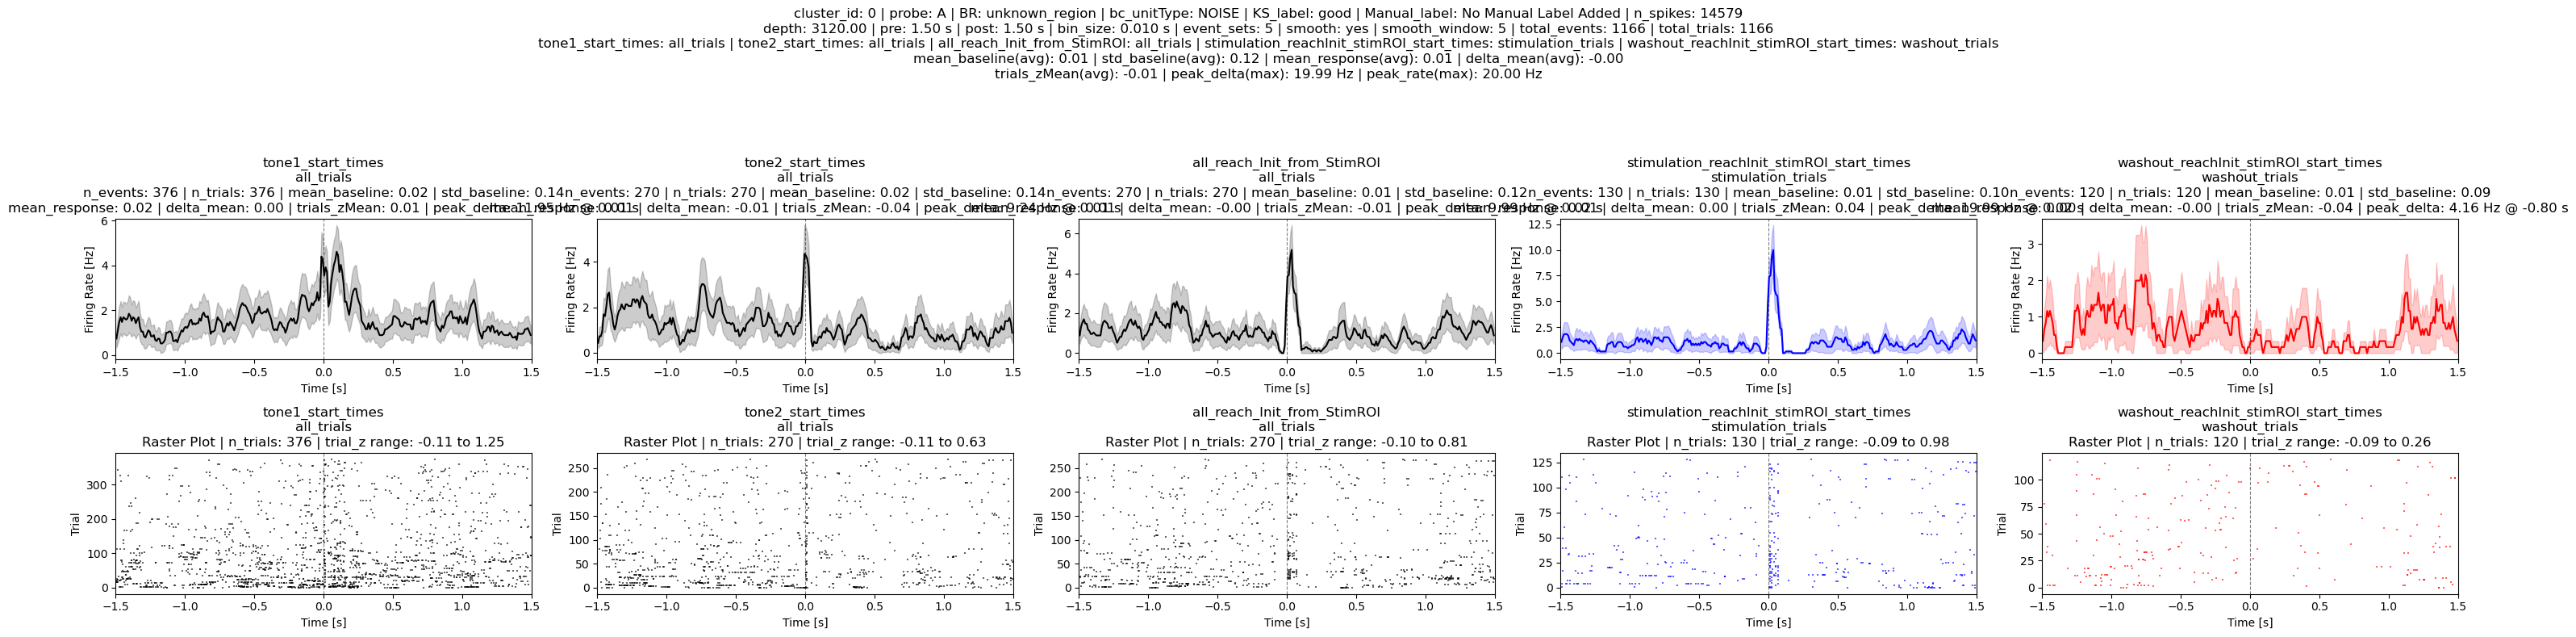

In [31]:
psth_raster.singleUnit_psth_raster_subplots(
    df_units=df_plot_units,
    probeLetter=probeLetter,
    cluster_id=cluster_id,
    event_name_subplots=event_name_subplots,
    pre=pre,
    post=post,
    bin_size=bin_size,
    namespace=globals(),
)

(<Figure size 3000x1800 with 25 Axes>,
 array([[<Axes: title={'center': 'tone1_start_times\nBaseline PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'tone2_start_times\nBaseline PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'all_reach_Init_from_StimROI\nBaseline PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'stimulation_reachInit_stimROI_start_times\nBaseline PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'washout_reachInit_stimROI_start_times\nBaseline PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>],
        [<Axes: title={'center': 'tone1_start_times\nStimulation PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'tone2_start_times\nStimulation PSTH'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
         <Axes: title={'center': 'all_reach_Init_from_StimROI\nStimulation PSTH'}

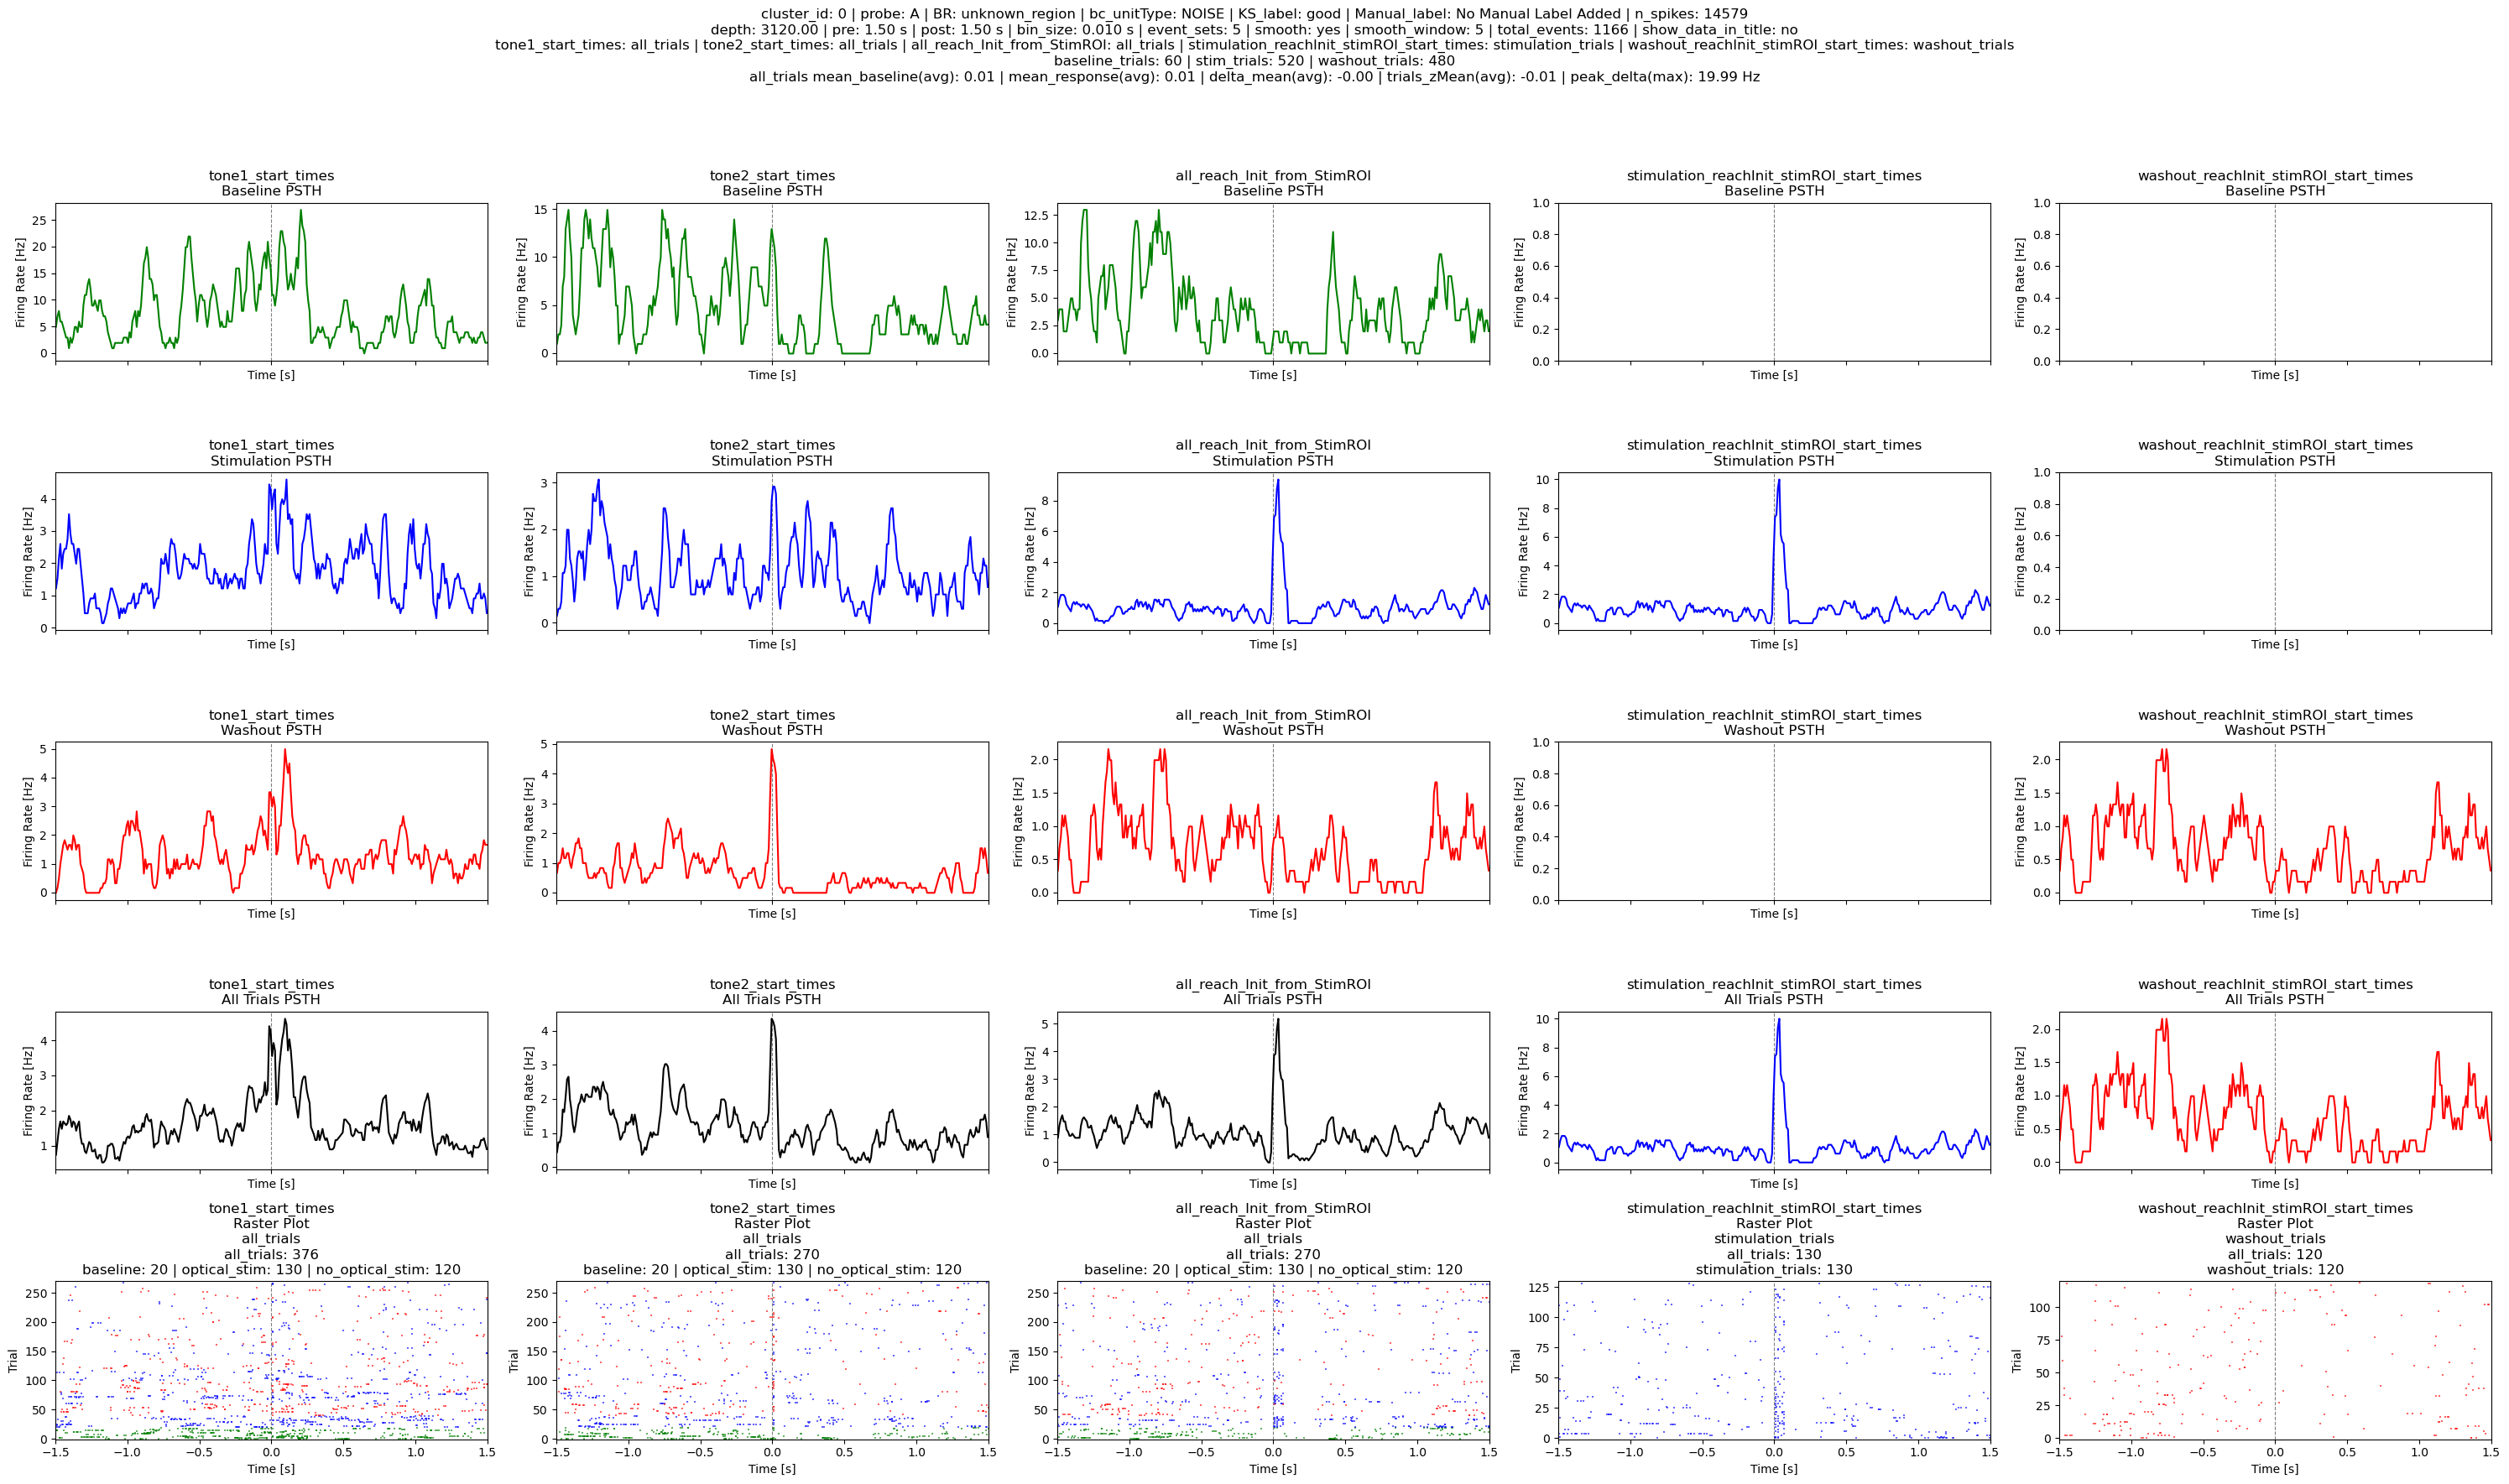

In [32]:
psth_raster.singleUnit_psth_raster_subplots_stim_seperated(
    df_units=df_plot_units,
    probeLetter=probeLetter,
    cluster_id=cluster_id,
    event_name_subplots=event_name_subplots,
    trail_indices=trial_indices_stim_seperated,
    pre=pre,
    post=post,
    bin_size=bin_size,
    namespace=globals(),
    smooth=True,
    show_data_in_title=False,

    var_bars=False,
)

(<Figure size 1200x3120 with 12 Axes>,
 array([<Axes: title={'center': 'baseline_epoch\nn_events: 20 | n_trials: 20 | mean_baseline: 0.05 | std_baseline: 0.26\nmean_response: 0.03 | delta_mean: -0.02 | trials_zMean: -0.08 | peak_delta: 29.95 Hz @ -1.32 s'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
        <Axes: title={'center': 'stimulation_epoch_1\nn_events: 20 | n_trials: 20 | mean_baseline: 0.02 | std_baseline: 0.16\nmean_response: 0.03 | delta_mean: 0.01 | trials_zMean: 0.06 | peak_delta: 39.98 Hz @ 0.03 s'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
        <Axes: title={'center': 'washout_epoch_1\nn_events: 20 | n_trials: 20 | mean_baseline: 0.02 | std_baseline: 0.15\nmean_response: 0.01 | delta_mean: -0.01 | trials_zMean: -0.07 | peak_delta: 19.98 Hz @ -1.08 s'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
        <Axes: title={'center': 'stimulation_epoch_2\nn_events: 20 | n_trials: 20 | mean_baseline: 0.01 | std_baseline: 0.10\nmean_response: 0.02 | delta_mean: 

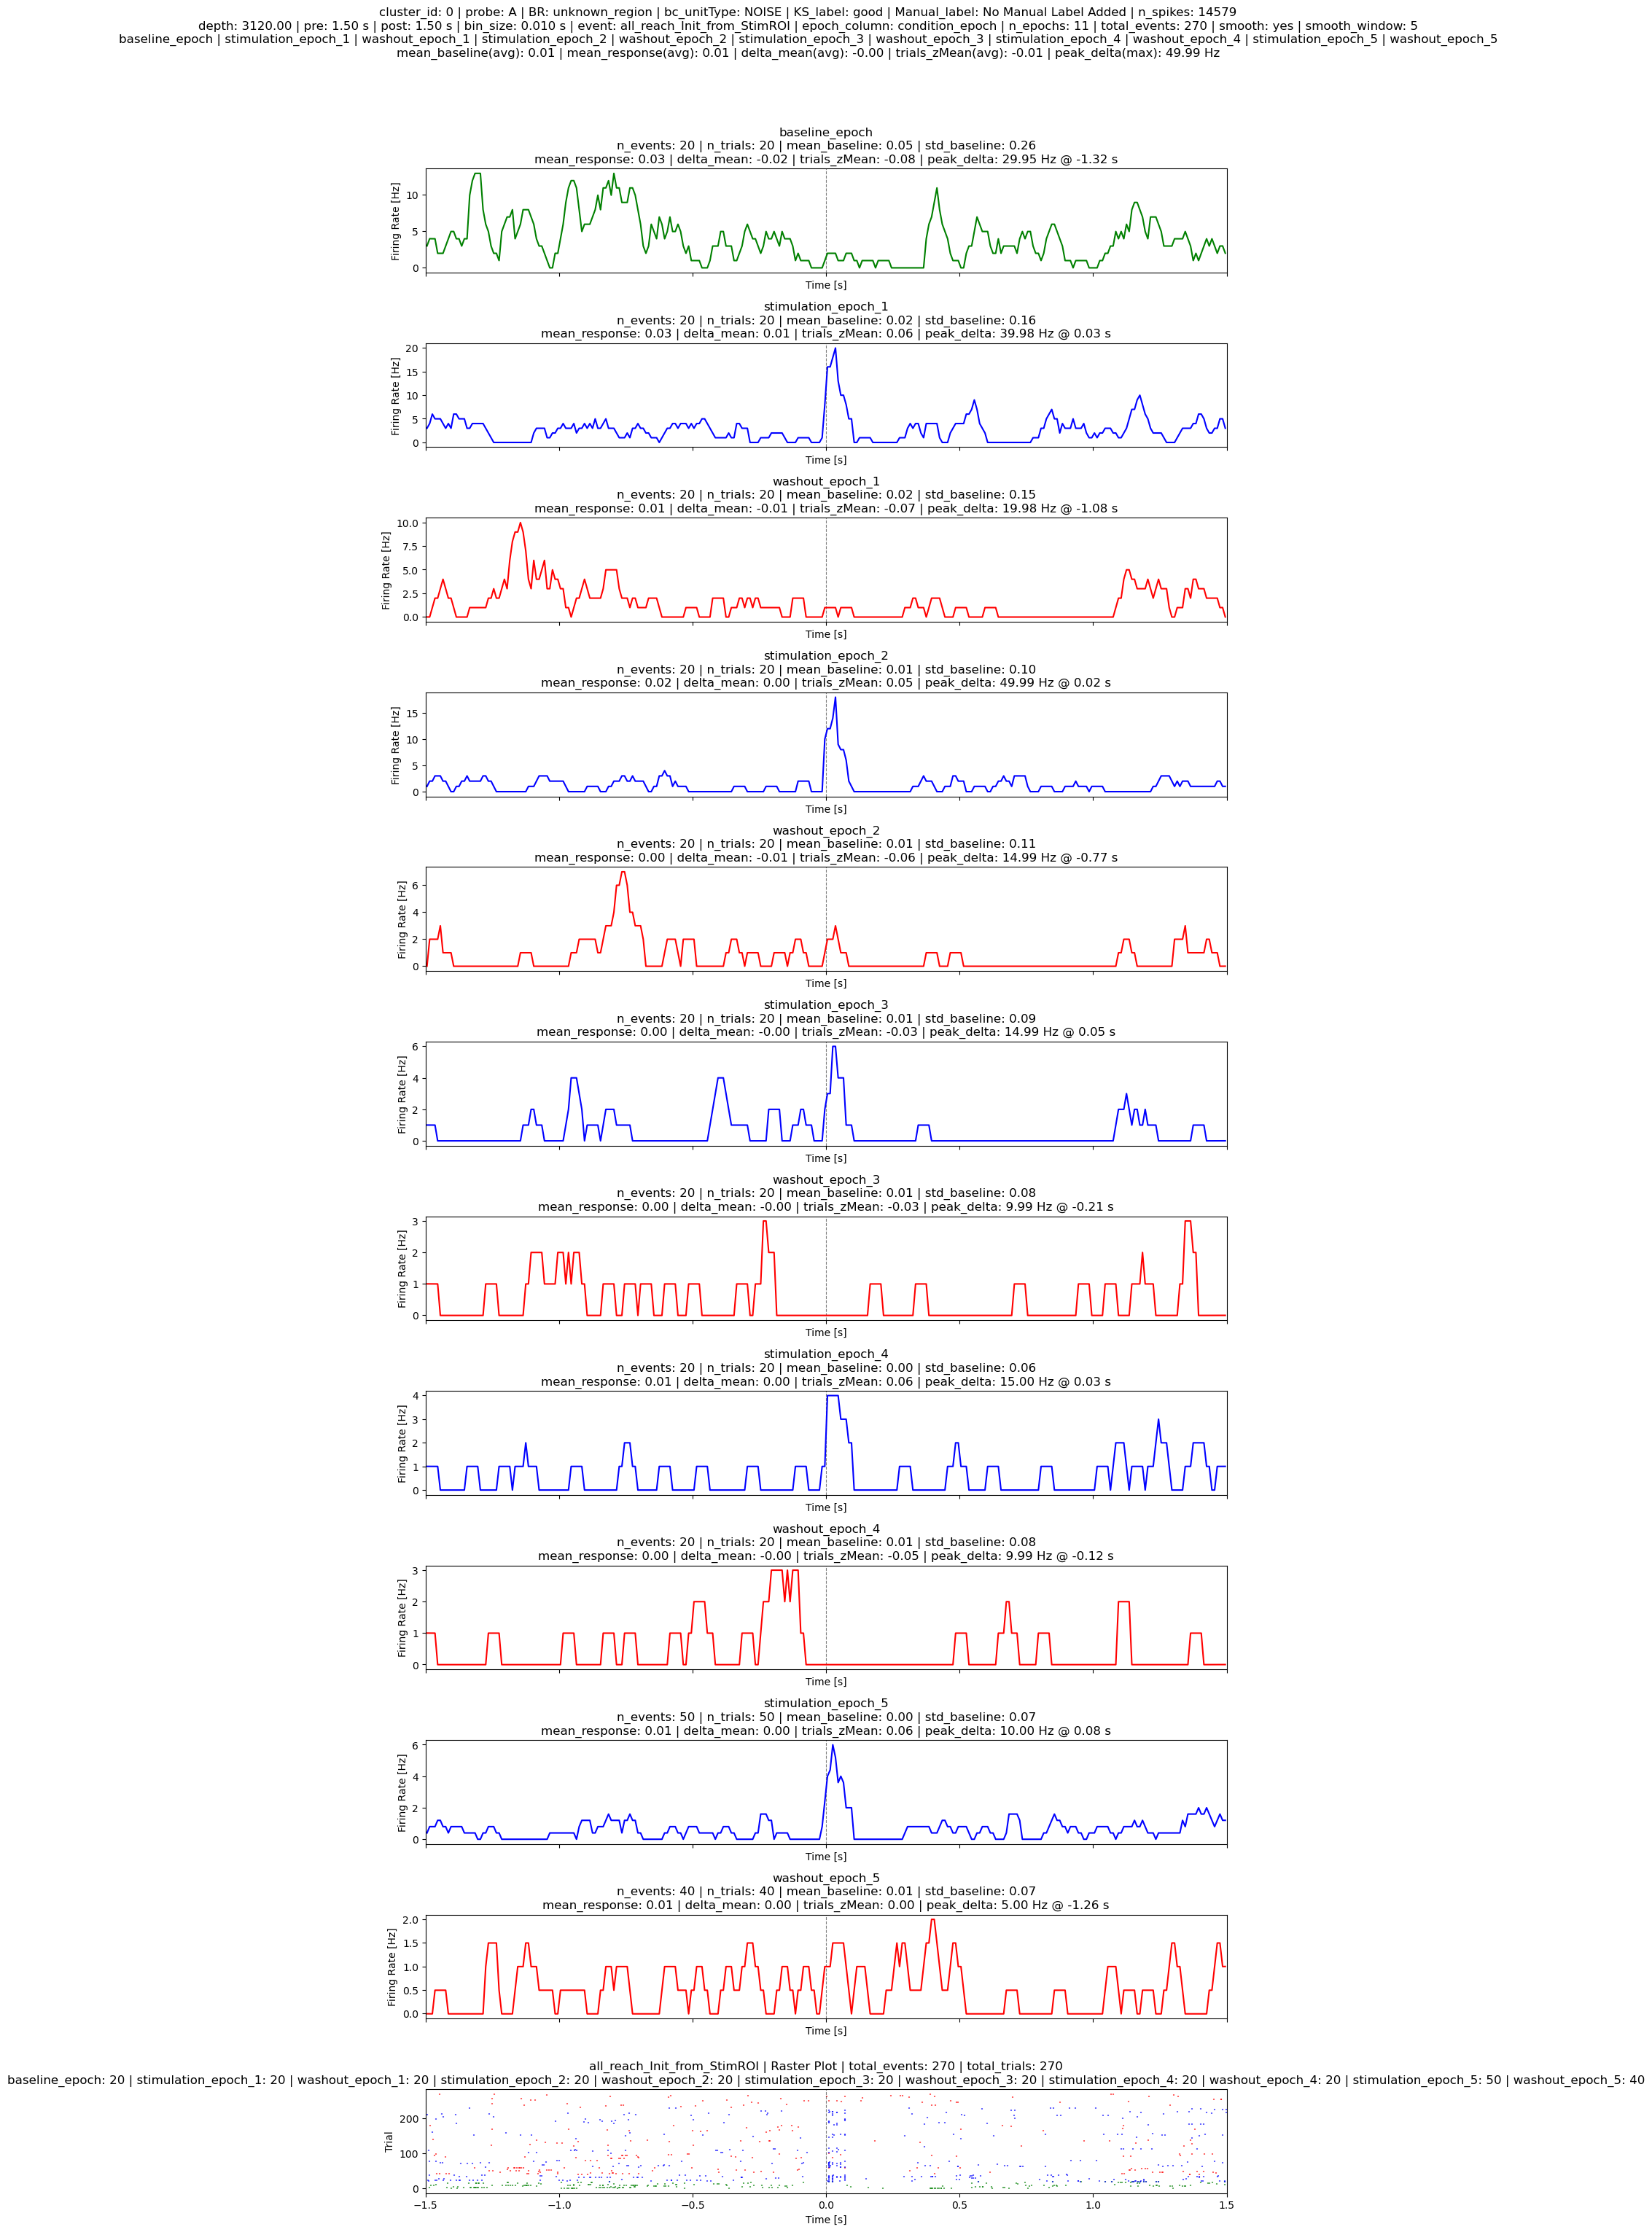

In [33]:
psth_raster.singleUnit_psth_raster_epoch_stacked(
    df_units=df_plot_units,
    probeLetter=probeLetter,
    cluster_id=cluster_id,
    event_times=all_reach_Init_from_StimROI,
    event_name='all_reach_Init_from_StimROI',
    event_meta=pca_event_meta_aligned,
    epoch_column='condition_epoch',
    pre=pre,
    post=post,
    bin_size=bin_size,
    namespace=globals(),
    smooth=True,
    var_bars=False,
    smooth_window=5,
    show_data_in_title=True,
)

## Small Batch Examples

#### Verify df_probe_subset

In [34]:
df_probe_subset

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI_x,Brain_Region_x,...,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,bc_ROI_y,Brain_Region_y,in_brainRegion,Brain_Region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,...,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,IP,NaN,NaN
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,...,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,IP,NaN,NaN
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,...,"[9938.897430842511, 9940.381573391209, 9941.04...",3,386.0,403.393829,98,NOISE,IN_ROI,IP,NaN,NaN
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,...,"[9938.29451763671, 9938.519134975282, 9938.609...",4,10164.0,614.671204,103,NOISE,IN_ROI,IP,NaN,NaN
6,2625.0,59.0,525.0,0,2,9.4,0.0,A,IN_ROI,IP,...,"[9938.36745660027, 9938.550204039331, 9938.722...",6,854.0,674.749634,119,NOISE,IN_ROI,IP,NaN,NaN


In [35]:
example_batch_dir = output_root / 'batch_examples'
example_batch_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving batch example outputs to: {example_batch_dir}\n")
print("Example batch will use the following units:")
display(df_probe_subset)
example_batch_results = {
    'allUnits_psth_raster_2': psth_raster.allUnits_psth_raster_2(
        df_units=df_probe_subset,
        df_stim=df_stim,
        brain_region=brain_region_filter,
        title_name='all_stimROI_triggers_start_times',
        event_times=all_stimROI_triggers_start_times,
        KSlabel=example_use_kslabel,
        all_units=True,
        pre=pre,
        post=post,
        bin_size=0.025,
        probeLetter=probeLetter,
        save_dir=example_batch_dir / 'allUnits_psth_raster_2',
    ),
    'allUnits_select_eventTimes': psth_raster.allUnits_psth_raster_select_eventTimes(
        df_units=df_probe_subset,
        df_stim=df_stim,
        probeLetter=probeLetter,
        brain_region=brain_region_filter,
        event_times_to_use=tone2_start_times,
        KSlabel=example_use_kslabel,
        pre=pre,
        post=post,
        binSizeRaster=0.025,
        save_dir=example_batch_dir / 'allUnits_select_eventTimes',
    ),
    'allUnits_epoch_from_df_stim': psth_raster.allUnits_psth_raster_figures(
        df_units=df_probe_subset,
        df_stim=df_stim,
        probeLetter=probeLetter,
        brain_region=brain_region_filter,
        KSlabel=example_use_kslabel,
        pre=pre,
        post=post,
        binSizeRaster=0.025,
        epoch1='pellet_detected_timestamp',
        save_dir=example_batch_dir / 'allUnits_epoch_from_df_stim',
    ),
}
example_batch_results

Saving batch example outputs to: H:\PSTH_RASTER_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\batch_examples

Example batch will use the following units:


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI_x,Brain_Region_x,...,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,bc_ROI_y,Brain_Region_y,in_brainRegion,Brain_Region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,...,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,IP,NaN,NaN
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,...,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,IP,NaN,NaN
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,...,"[9938.897430842511, 9940.381573391209, 9941.04...",3,386.0,403.393829,98,NOISE,IN_ROI,IP,NaN,NaN
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,...,"[9938.29451763671, 9938.519134975282, 9938.609...",4,10164.0,614.671204,103,NOISE,IN_ROI,IP,NaN,NaN
6,2625.0,59.0,525.0,0,2,9.4,0.0,A,IN_ROI,IP,...,"[9938.36745660027, 9938.550204039331, 9938.722...",6,854.0,674.749634,119,NOISE,IN_ROI,IP,NaN,NaN


c:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\PSTH_raster.py:627: RuntimeWarning: Mean of empty slice
  mean_baseline = float(np.nanmean(baseline_window))
c:\Users\user\anaconda3\envs\reaching_task\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\PSTH_raster.py:629: RuntimeWarning: Mean of empty slice
  mean_response = float(np.nanmean(response_window))
c:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\PSTH_raster.py:397: RuntimeWarning: Mean of empty slice
  scalar = float(np.nanmean(arr))


{'allUnits_psth_raster_2': [WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/batch_examples/allUnits_psth_raster_2/clusterID_0_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/batch_examples/allUnits_psth_raster_2/clusterID_1_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/batch_examples/allUnits_psth_raster_2/clusterID_3_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/batch_examples/allUnits_psth_raster_2/clusterID_4_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/batch_examples/allUnits_psth_raster_2/clusterID_6_probeA_unknown_region.png')],
 'allUnits_select_eventTimes': [WindowsPath('H:/PSTH_RASTE

## Multi-Event Plotting Variants

In [36]:
example_multi_event_dir = output_root / 'multi_event_examples'
example_multi_event_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving multi-event example outputs to: {example_multi_event_dir}")

example_multi_event_results = {
    'stim_separated': psth_raster.psth_raster_stim_seperated(
        df_units=df_probe_subset,
        df_stim=df_stim,
        brain_region=brain_region_filter,
        event_name='all_reach_Init_from_StimROI',
        trail_indices=trial_indices_stim_seperated,
        event_times=all_reach_Init_from_StimROI,
        KSlabel=example_use_kslabel,
        pre=pre,
        post=post,
        bin_size=0.025,
        probeLetter=probeLetter,
        save_dir=example_multi_event_dir / 'stim_separated',
    ),
    'all_events_separated': psth_raster.psth_raster_all_events_seperated(
        df_units=df_probe_subset,
        df_stim=df_stim,
        brain_region=brain_region_filter,
        variables=variables,
        trail_indices=trial_indices_stim_seperated,
        KSlabel=example_use_kslabel,
        pre=pre,
        post=post,
        bin_size=0.025,
        probeLetter=probeLetter,
        save_dir=example_multi_event_dir / 'all_events_separated',
    ),
    'all_events_plus_opto': psth_raster.psth_raster_all_events_seperated_plus_opto(
        df_units=df_probe_subset,
        df_stim=df_stim,
        brain_region=brain_region_filter,
        variables=variables,
        trail_indices=trial_indices_stim_seperated,
        KSlabel=example_use_kslabel,
        pre=pre,
        post=post,
        bin_size=0.025,
        probeLetter=probeLetter,
        save_dir=example_multi_event_dir / 'all_events_plus_opto',
    ),
    'all_events_by_color': psth_raster.psth_raster_all_events_seperated_by_color(
        df_units=df_probe_subset,
        df_stim=df_stim,
        brain_region=brain_region_filter,
        variables=variables,
        trail_indices=trial_indices_stim_seperated,
        KSlabel=example_use_kslabel,
        pre=pre,
        post=post,
        bin_size=0.025,
        probeLetter=probeLetter,
        save_dir=example_multi_event_dir / 'all_events_by_color',
    ),
}
example_multi_event_results

Saving multi-event example outputs to: H:\PSTH_RASTER_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\multi_event_examples


{'stim_separated': [WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/multi_event_examples/stim_separated/clusterID_0_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/multi_event_examples/stim_separated/clusterID_1_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/multi_event_examples/stim_separated/clusterID_3_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/multi_event_examples/stim_separated/clusterID_4_probeA_unknown_region.png'),
  WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/multi_event_examples/stim_separated/clusterID_6_probeA_unknown_region.png')],
 'all_events_separated': [WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_s

## Multi-Region Views

In [20]:
df_plot_units

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI_x,Brain_Region_x,...,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,bc_ROI_y,Brain_Region_y,in_brainRegion,Brain_Region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,...,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,IP,NaN,NaN
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,...,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,IP,NaN,NaN
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,...,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,IP,NaN,NaN
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,...,"[9938.897430842511, 9940.381573391209, 9941.04...",3,386.0,403.393829,98,NOISE,IN_ROI,IP,NaN,NaN
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,...,"[9938.29451763671, 9938.519134975282, 9938.609...",4,10164.0,614.671204,103,NOISE,IN_ROI,IP,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,860.0,43.0,3740.0,0,1,10.2,175.3,F,NaN,NaN,...,"[9939.57044788735, 9939.597083318817, 9939.703...",686,14462.0,7.135010,370,NON-SOMA: troughToPeak2Ratio<minTroughToPeak2R...,NaN,NaN,OUT_ROI,None
4596,1020.0,43.0,3580.0,0,2,19.5,0.0,F,NaN,NaN,...,"[10919.660133182651, 10919.6751343645, 10919.7...",687,187.0,3730.237549,354,NOISE: spatialDecaySlope<minSpatialDecaySlopeExp,NaN,NaN,OUT_ROI,None
4597,1060.0,11.0,3540.0,0,1,9.6,236.7,F,NaN,NaN,...,"[9996.778036617923, 10049.712567383913, 10050....",688,1879.0,3756.871338,351,NOISE: spatialDecaySlope<minSpatialDecaySlopeExp,NaN,NaN,OUT_ROI,None
4598,980.0,43.0,3620.0,0,2,26.1,0.0,F,NaN,NaN,...,"[10919.650099059141, 10919.665100240469, 10919...",689,949.0,13.793701,358,NON-SOMA: troughToPeak2Ratio<minTroughToPeak2R...,NaN,NaN,OUT_ROI,None


In [40]:
example_multi_region_dir = output_root / 'multi_region_examples'
example_multi_region_dir.mkdir(parents=True, exist_ok=True)

psth_raster.multiRegion_raster_figures(
    df_units=df_plot_units,
    df_stim=df_stim,
    brain_regions=multi_region_labels,
    probe_units=multi_region_units,
    probe_letters=multi_probe_letters,
    KSlabel=example_use_kslabel,
    pre=pre,
    post=post,
    binSizeRaster=0.025,
    epoch1='all_reach_Init_from_StimROI',
    save_dir=example_multi_region_dir,
)

psth_raster.multiRegion_raster_psth_figures(
    df_units=df_plot_units,
    df_stim=df_stim,
    brain_regions=multi_region_labels,
    probe_units=multi_region_units,
    probe_letters=multi_probe_letters,
    KSlabel=example_use_kslabel,
    pre=pre,
    post=post,
    binSizeRaster=0.025,
    binSizePSTH=0.025,
    epoch1='all_reach_Init_from_StimROI',
    save_dir=example_multi_region_dir,
)

psth_raster.multiRegion_raster_psth_normalized(
    df_units=df_plot_units,
    df_stim=df_stim,
    brain_regions=multi_region_labels,
    probe_units=multi_region_units,
    probe_letters=multi_probe_letters,
    KSlabel=example_use_kslabel,
    pre=pre,
    post=post,
    binSizeRaster=0.025,
    binSizePSTH=0.025,
    event_times=all_reach_Init_from_StimROI,
    save_dir=example_multi_region_dir,
)

WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/multi_region_examples/multi_region_psth_raster_units_[0, 1, 0, 1, 5, 0].png')

## Heatmaps

In [37]:
multi_probe_letters

['A', 'B', 'C', 'D', 'E', 'F']

(<Figure size 1600x2400 with 12 Axes>,
 array([<Axes: title={'center': 'Probe A'}, xlabel='Time (s)', ylabel='unknown_region'>,
        <Axes: title={'center': 'Probe B'}, xlabel='Time (s)', ylabel='PG'>,
        <Axes: title={'center': 'Probe C'}, xlabel='Time (s)', ylabel='MoP'>,
        <Axes: title={'center': 'Probe D'}, xlabel='Time (s)', ylabel='VaL'>,
        <Axes: title={'center': 'Probe E'}, xlabel='Time (s)', ylabel='SnR'>,
        <Axes: title={'center': 'Probe F'}, xlabel='Time (s)', ylabel='RN'>],
       dtype=object),
 WindowsPath('H:/PSTH_RASTER_OUT/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/heatmaps/multi_probe_heatmap_smoothed_all_reach_Init_from_StimROI_1.5_1.5.png'))

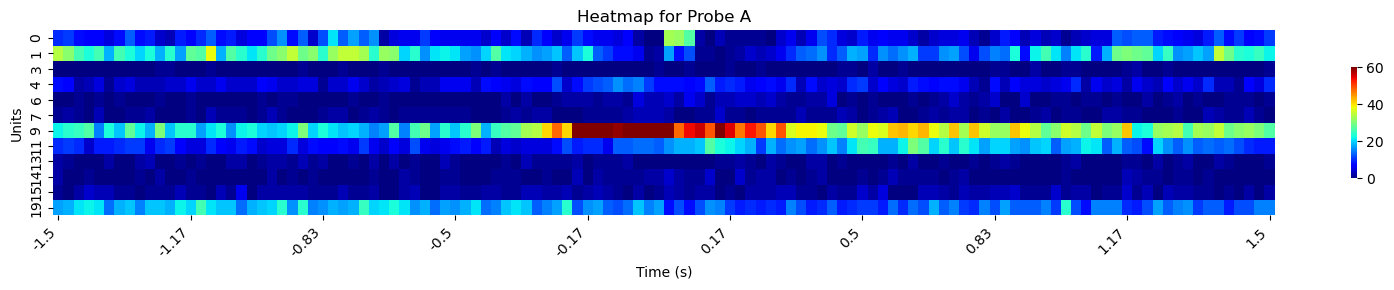

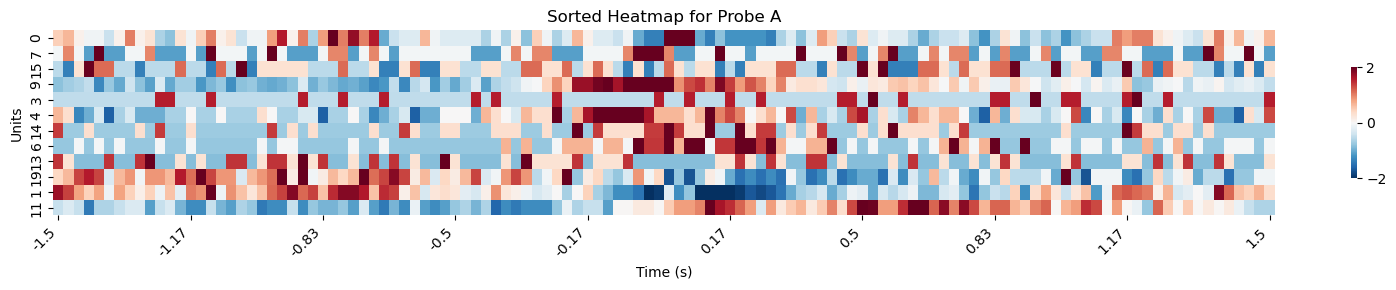

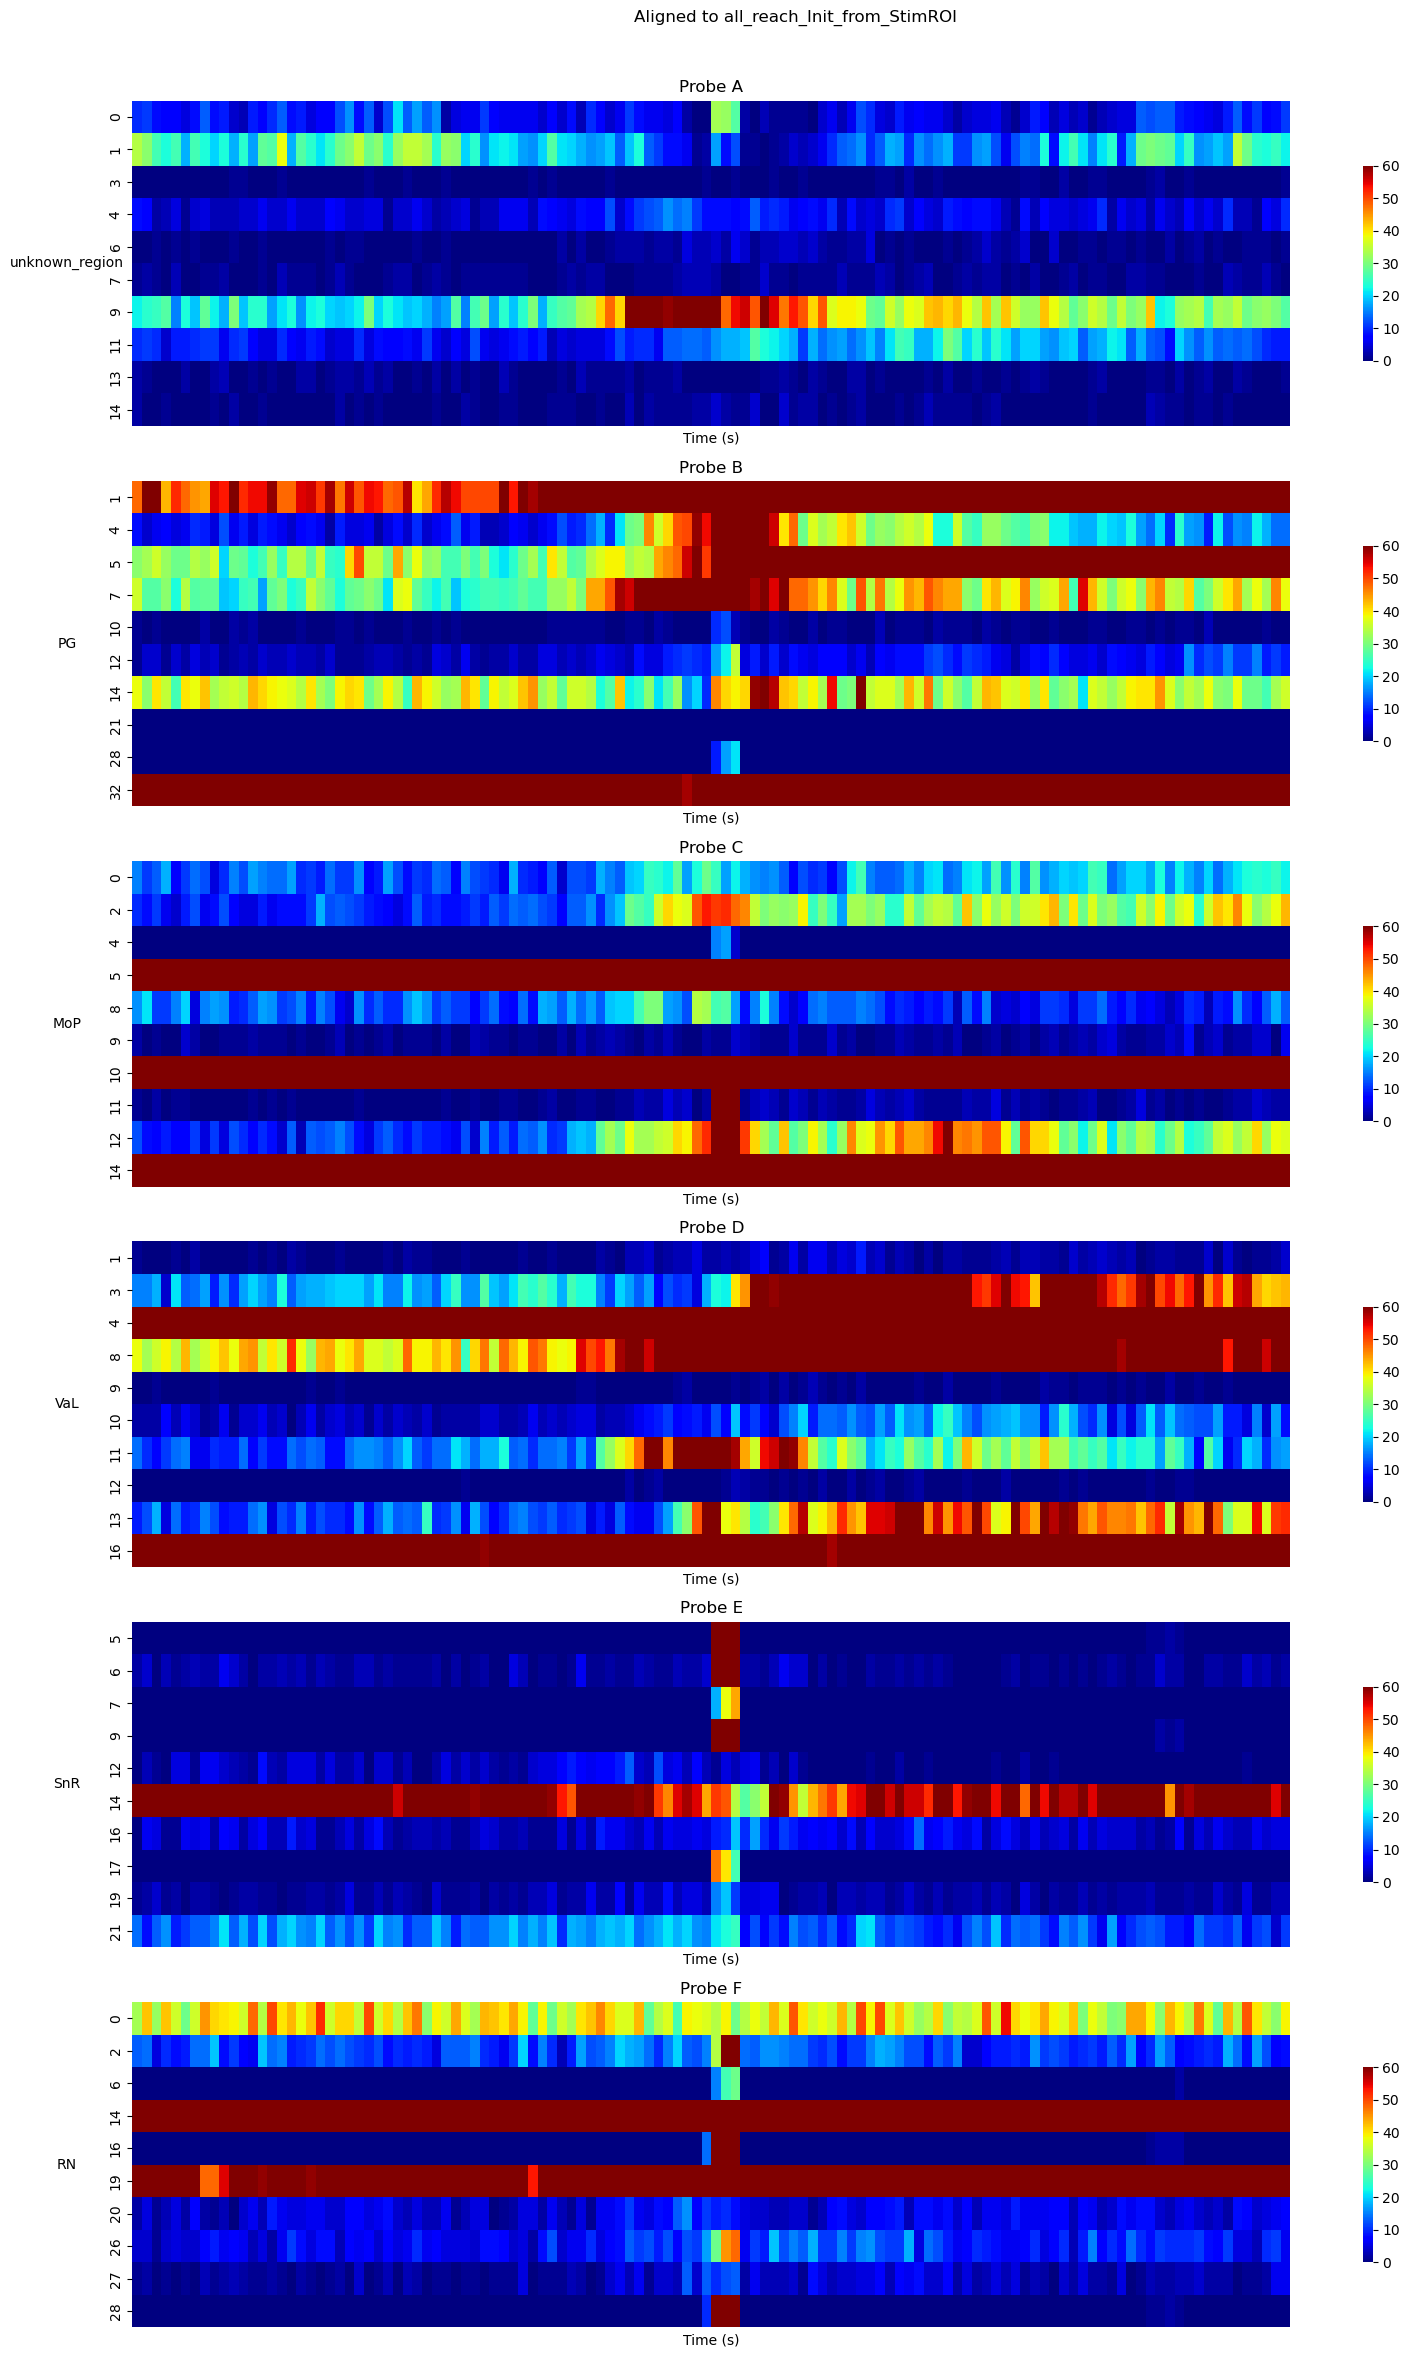

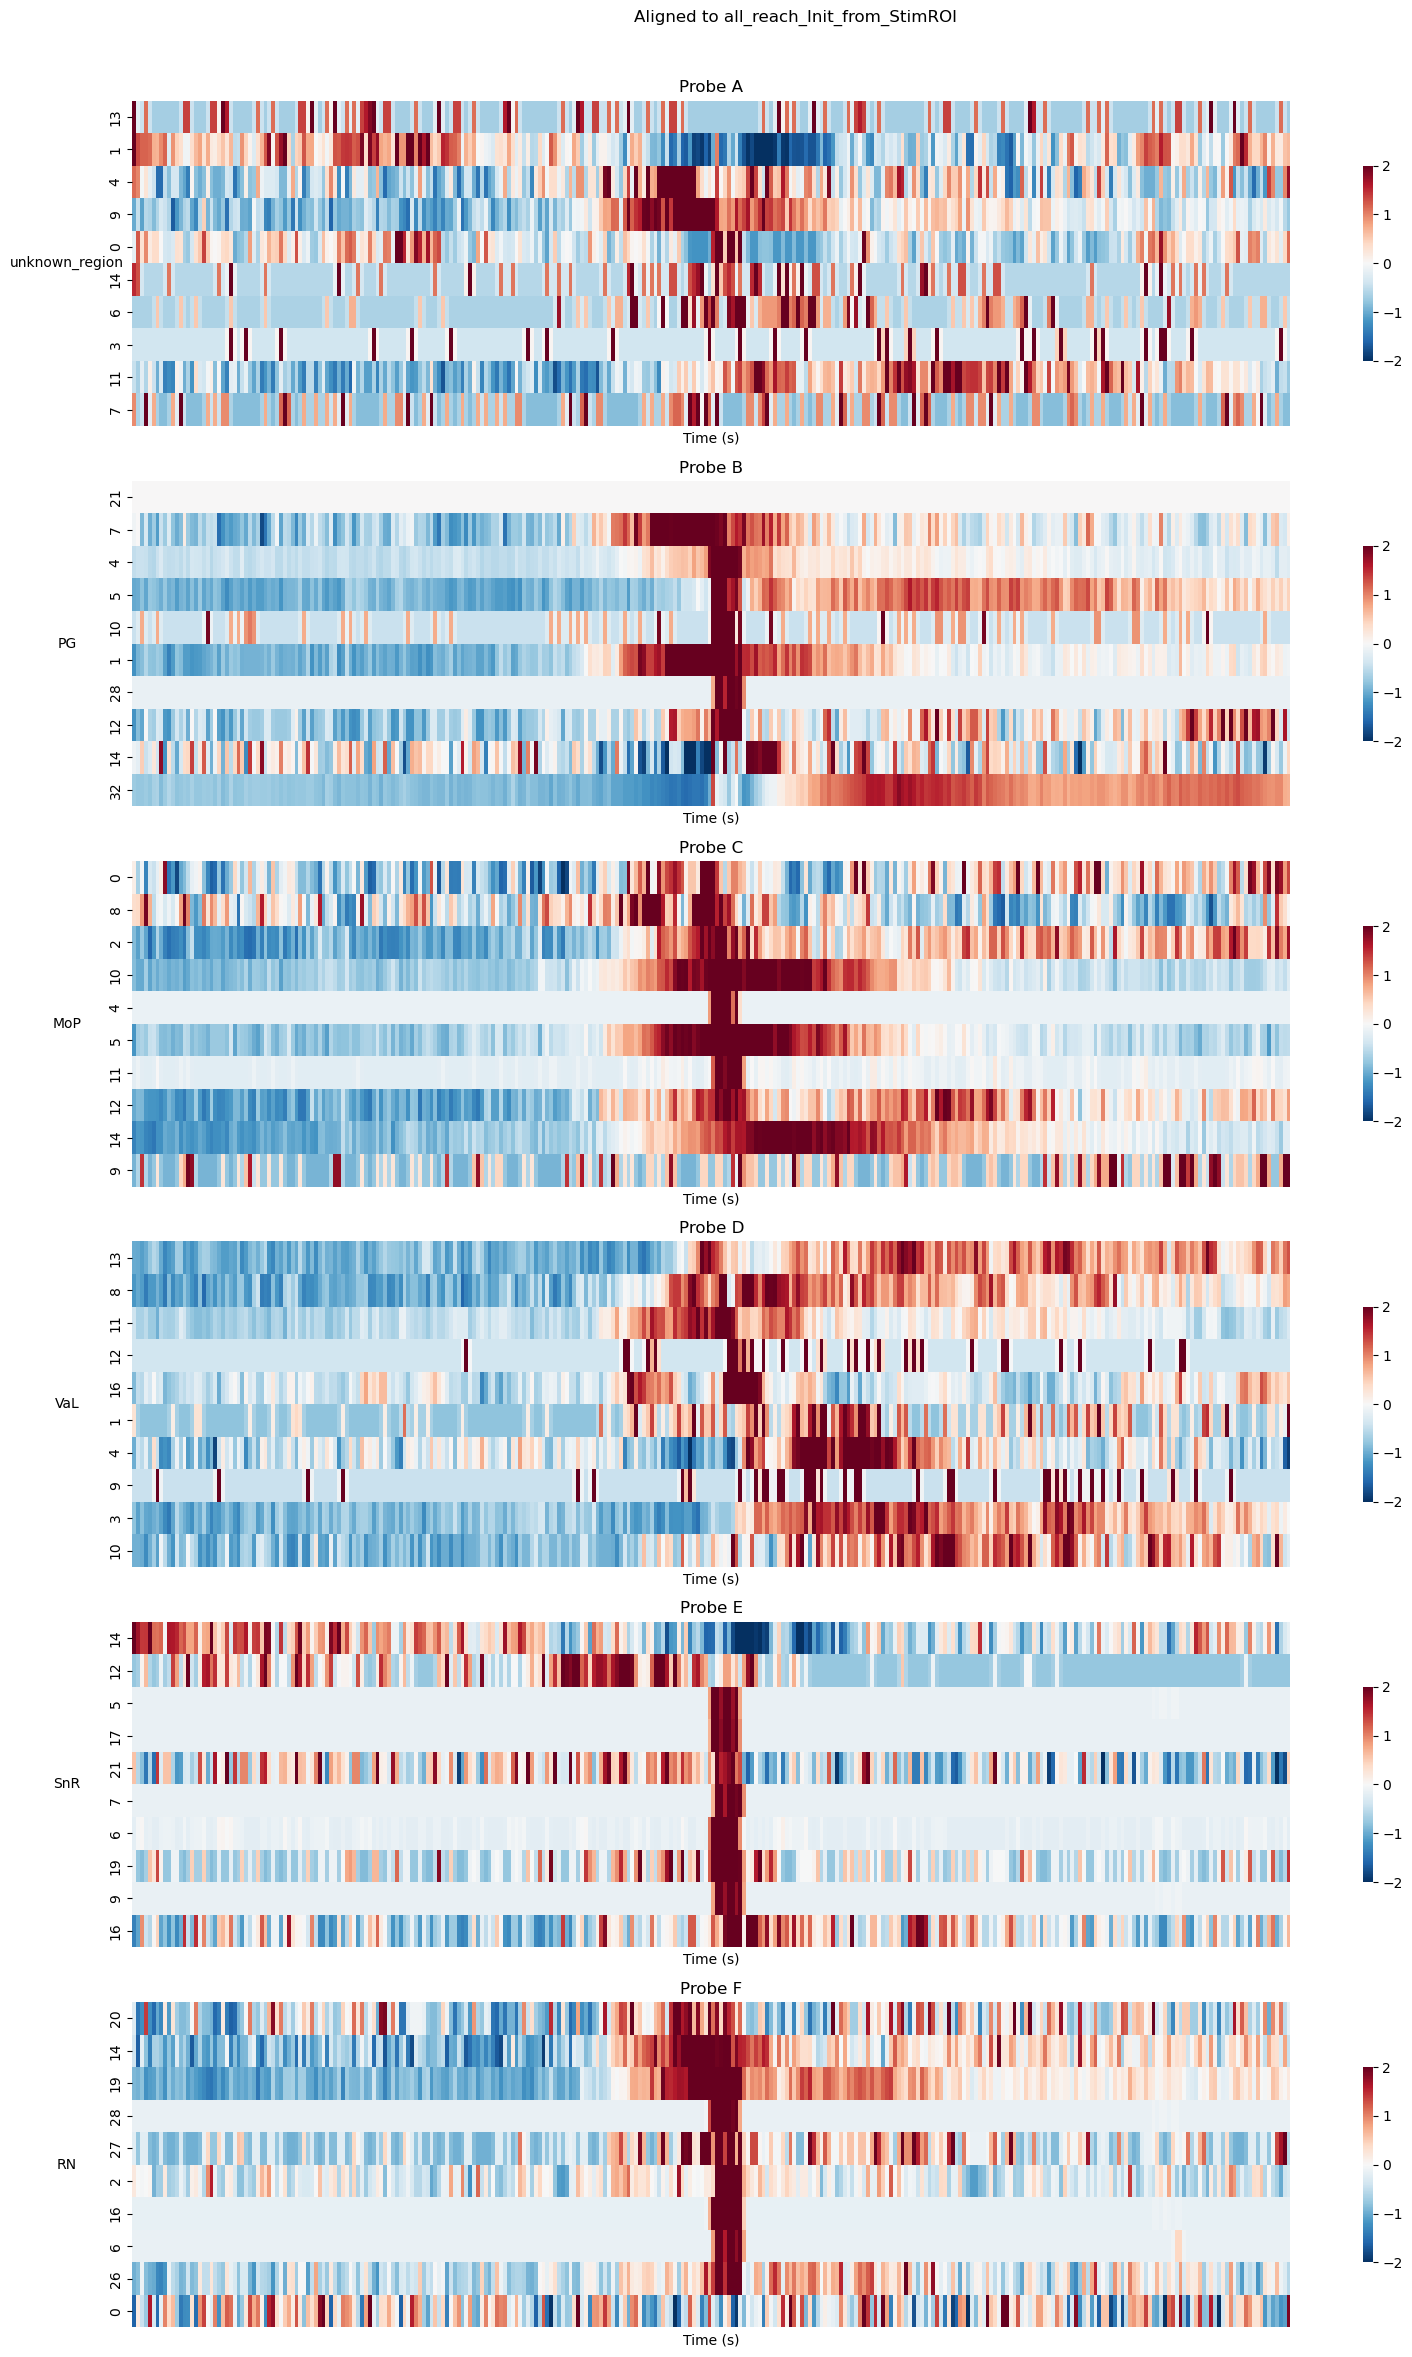

In [38]:
example_heatmap_dir = output_root / 'heatmaps'
example_heatmap_dir.mkdir(parents=True, exist_ok=True)

psth_raster.probe_units_heatmap(
    df_units=df_plot_units,
    df_stim=df_stim,
    probeLetter=probeLetter,
    selected_units=selected_units_for_heatmap,
    event_times=all_reach_Init_from_StimROI,
    pre=pre,
    post=post,
    bin_size=0.025,
    KSlabel=example_use_kslabel,
    save_dir=example_heatmap_dir,
    max_fr=60,
    show_unit_labels=True,
    normalize_fr=False,
)

psth_raster.sorted_heatmap(
    df_units=df_plot_units,
    df_stim=df_stim,
    probeLetter=probeLetter,
    selected_units=selected_units_for_heatmap,
    event_times=all_reach_Init_from_StimROI,
    pre=pre,
    post=post,
    bin_size=0.025,
    KSlabel=example_use_kslabel,
    save_dir=example_heatmap_dir,
    normalize_fr=True,
)

psth_raster.multi_probe_units_heatmap(
    df_units=df_plot_units,
    df_stim=df_stim,
    probes=multi_probe_letters,
    selected_units=selected_units_by_probe,
    times_of_events=all_reach_Init_from_StimROI,
    event_name='all_reach_Init_from_StimROI',
    brain_regions=multi_region_labels,
    pre=pre,
    post=post,
    bin_size=0.025,
    KSlabel=example_use_kslabel,
    save_dir=example_heatmap_dir,
)

psth_raster.multi_probe_units_heatmap_smoothed(
    df_units=df_plot_units,
    df_stim=df_stim,
    probes=multi_probe_letters,
    selected_units=selected_units_by_probe,
    times_of_events=all_reach_Init_from_StimROI,
    event_name='all_reach_Init_from_StimROI',
    brain_regions=multi_region_labels,
    pre=pre,
    post=post,
    bin_size=0.01,
    KSlabel=example_use_kslabel,
    save_dir=example_heatmap_dir,
    normalize_fr=True,
    smoothing_window=0.5,
)